# V1 — Personal Running Activity Analysis
**Tujuan utama:** menjawab pertanyaan:
"How has my running activity and performance changed over time?"

Scope V1:
- Hanya memakai activities.csv dari Strava export
- Hanya aktivitas dengan Activity Type == "Run"
- Fokus pada distance, moving time, pace, frequency, dan calendar pattern
- Belum memakai SQL, Power BI, FIT/GPX, GPS, weather, atau heart-rate analysis

File ini dirancang untuk VS Code Python Interactive Cells.
Jalankan cell satu per satu dengan tombol "Run Cell".



In [70]:
# CELL 1 — Import library dan konfigurasi tampilan
# Analisis: belum menganalisis data; hanya menyiapkan environment Python.

from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print("Library berhasil di-import.")



Library berhasil di-import.


In [71]:
# CELL 2 — Menentukan struktur folder project
# Analisis: memastikan input/output project tersusun rapi dan reproducible.
#
# PENTING:
# Buka folder root project di VS Code sebelum menjalankan file ini.
#
# Struktur yang diharapkan:
# strava-running-analysis/
# ├── data/
# │   ├── raw/
# │   │   └── export_194541743.zip
# │   └── processed/
# ├── images/
# │   └── charts/
# └── v1_running_analysis.ipynb

PROJECT_ROOT = Path.cwd()

# Fallback jika current working directory berada satu level di bawah root.
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CHART_DIR = PROJECT_ROOT / "images" / "charts"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = RAW_DIR / "export_194541743.zip"

# Hindari mencetak absolute path pengguna pada notebook publik.
print("Project structure initialized.")
print("Raw ZIP       : data/raw/export_194541743.zip")
print("ZIP exists?   :", ZIP_PATH.exists())

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        "File export_194541743.zip tidak ditemukan.\n"
        "Letakkan file tersebut di folder data/raw/."
    )

Project structure initialized.
Raw ZIP       : data/raw/export_194541743.zip
ZIP exists?   : True


In [72]:
# CELL 3 — Audit isi ZIP
# Analisis:
# - memastikan activities.csv benar-benar ada
# - melihat jumlah file dalam export
# - tidak mengekstrak seluruh ZIP, sehingga lebih aman dan rapi

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    zip_files = z.namelist()

print(f"Total file/entry di ZIP: {len(zip_files):,}")

activity_csv_candidates = [
    name for name in zip_files
    if name.lower().endswith("activities.csv")
]

print("activities.csv ditemukan:", activity_csv_candidates)

if len(activity_csv_candidates) != 1:
    raise ValueError(
        "activities.csv tidak ditemukan secara unik di dalam ZIP."
    )

ACTIVITIES_FILE = activity_csv_candidates[0]



Total file/entry di ZIP: 245
activities.csv ditemukan: ['activities.csv']


In [73]:
# CELL 4 — Load activities.csv langsung dari ZIP
# Analisis:
# - membaca dataset utama
# - mengecek jumlah baris dan kolom
#
# Raw row preview sengaja tidak ditampilkan pada notebook publik
# untuk menghindari exposure identifier atau metadata mentah.

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    with z.open(ACTIVITIES_FILE) as f:
        activities_raw = pd.read_csv(f)

print("Shape dataset:", activities_raw.shape)
print(
    f"Dataset loaded successfully: "
    f"{activities_raw.shape[0]:,} rows × "
    f"{activities_raw.shape[1]:,} columns"
)

Shape dataset: (185, 103)
Dataset loaded successfully: 185 rows × 103 columns


In [74]:
# CELL 5 — Memahami struktur dataset
# Analisis:
# - daftar seluruh kolom
# - tipe data awal
# - jenis aktivitas yang terdapat pada dataset

print(f"Jumlah baris : {activities_raw.shape[0]:,}")
print(f"Jumlah kolom : {activities_raw.shape[1]:,}")

print("\nDaftar kolom:")
for i, col in enumerate(activities_raw.columns, start=1):
    print(f"{i:>3}. {col}")

print("\nDistribusi Activity Type:")
display(
    activities_raw["Activity Type"]
    .value_counts(dropna=False)
    .rename_axis("activity_type")
    .reset_index(name="count")
)



Jumlah baris : 185
Jumlah kolom : 103

Daftar kolom:
  1. Activity ID
  2. Activity Date
  3. Activity Name
  4. Activity Type
  5. Activity Description
  6. Elapsed Time
  7. Distance
  8. Max Heart Rate
  9. Relative Effort
 10. Commute
 11. Activity Private Note
 12. Activity Gear
 13. Filename
 14. Athlete Weight
 15. Bike Weight
 16. Elapsed Time.1
 17. Moving Time
 18. Distance.1
 19. Max Speed
 20. Average Speed
 21. Elevation Gain
 22. Elevation Loss
 23. Elevation Low
 24. Elevation High
 25. Max Grade
 26. Average Grade
 27. Average Positive Grade
 28. Average Negative Grade
 29. Max Cadence
 30. Average Cadence
 31. Max Heart Rate.1
 32. Average Heart Rate
 33. Max Watts
 34. Average Watts
 35. Calories
 36. Max Temperature
 37. Average Temperature
 38. Relative Effort.1
 39. Total Work
 40. Number of Runs
 41. Uphill Time
 42. Downhill Time
 43. Other Time
 44. Perceived Exertion
 45. Type
 46. Start Time
 47. Weighted Average Power
 48. Power Count
 49. Prefer Perceived Ex

,activity_type,count
0,Run,126
1,Walk,48
2,Ride,7
3,Workout,2
4,Weight Training,2


In [75]:
# CELL 6 — Audit missing values pada dataset mentah
# Analisis:
# - mengukur completeness masing-masing kolom
# - memahami bahwa tidak semua 103 kolom cocok untuk V1
#
# Ini bukan berarti kita langsung drop semua kolom yang punya missing value.

missing_audit = pd.DataFrame({
    "column": activities_raw.columns,
    "missing_count": activities_raw.isna().sum().values,
    "missing_pct": (
        activities_raw.isna().mean().values * 100
    )
}).sort_values("missing_pct", ascending=False)

display(missing_audit.head(25))



,column,missing_count,missing_pct
51,Total Weight Lifted,185,100.00
38,Total Work,185,100.00
76,Jump Count,185,100.00
75,Weather Ozone,185,100.00
68,Bike,185,100.00
49,Perceived Relative Effort,185,100.00
45,Start Time,185,100.00
26,Average Positive Grade,185,100.00
27,Average Negative Grade,185,100.00
44,Type,185,100.00


In [76]:
# CELL 7 — Memilih kolom yang diperlukan untuk V1
# Analisis:
# V1 hanya membutuhkan variabel inti.
#
# Metric contract:
# - Distance      = jarak dalam km yang sudah dibulatkan oleh export
# - Distance.1    = jarak yang lebih presisi dalam meter
# - Moving Time   = detik
# - Average Speed = meter/detik
#
# Canonical distance V1:
# distance_km = Distance.1 / 1000
#
# Distance hanya digunakan sebagai cross-check jika diperlukan,
# bukan sebagai sumber utama perhitungan KPI.

DISTANCE_SOURCE_COLUMN = "Distance.1"

v1_columns = [
    "Activity ID",
    "Activity Date",
    "Activity Type",
    "Moving Time",
    DISTANCE_SOURCE_COLUMN,
    "Average Speed",
    "Max Speed",
    "Elevation Gain",
]

missing_required_columns = [
    col for col in v1_columns
    if col not in activities_raw.columns
]

if missing_required_columns:
    raise KeyError(
        f"Kolom berikut tidak ditemukan: {missing_required_columns}"
    )

activities = activities_raw[v1_columns].copy()

print("Kolom V1 berhasil dipilih.")
print("Shape setelah pemilihan kolom:", activities.shape)
print("Canonical distance source:", DISTANCE_SOURCE_COLUMN)

Kolom V1 berhasil dipilih.
Shape setelah pemilihan kolom: (185, 8)
Canonical distance source: Distance.1


In [77]:
# CELL 8 — Filter hanya aktivitas Run
# Analisis:
# - memisahkan aktivitas lari dari Walk, Ride, Workout, dll.
#
# Checkpoint dataset:
# 126 aktivitas Run.
#
# Raw activity rows tidak ditampilkan pada notebook publik
# karena masih mengandung original Activity ID dan timestamp.

runs = activities.loc[
    activities["Activity Type"].eq("Run")
].copy()

print(f"Total aktivitas Run: {len(runs):,}")

Total aktivitas Run: 126


In [78]:
# CELL 9 — Data quality check untuk data lari
# Analisis:
# - duplicate Activity ID
# - missing value pada kolom inti
# - nilai nol/negatif pada distance dan moving time
#
# Kita melakukan audit SEBELUM cleaning.

core_columns = [
    "Activity ID",
    "Activity Date",
    "Moving Time",
    "Distance.1",
]

quality_check = pd.DataFrame({
    "metric": [
        "Total rows",
        "Duplicate Activity ID",
        "Missing Activity Date",
        "Missing Moving Time",
        "Missing Distance.1",
        "Moving Time <= 0",
        "Distance.1 <= 0",
    ],
    "value": [
        len(runs),
        runs["Activity ID"].duplicated().sum(),
        runs["Activity Date"].isna().sum(),
        runs["Moving Time"].isna().sum(),
        runs["Distance.1"].isna().sum(),
        runs["Moving Time"].le(0).sum(),
        runs["Distance.1"].le(0).sum(),
    ]
})

display(quality_check)



,metric,value
0,Total rows,126
1,Duplicate Activity ID,0
2,Missing Activity Date,0
3,Missing Moving Time,0
4,Missing Distance.1,0
5,Moving Time <= 0,0
6,Distance.1 <= 0,0


In [79]:
# CELL 10 — Cleaning kolom inti
# Analisis:
# - parse tanggal
# - konversi numeric secara aman
# - hapus duplicate ID jika ada
# - buang hanya record yang tidak mungkin dianalisis:
#   missing/zero distance atau moving time
#
# Tidak ada filtering pace arbitrer di V1.

runs["activity_datetime"] = pd.to_datetime(
    runs["Activity Date"],
    format="%b %d, %Y, %I:%M:%S %p",
    errors="coerce"
)

numeric_columns = [
    "Moving Time",
    "Distance.1",
    "Average Speed",
    "Max Speed",
    "Elevation Gain",
]

for col in numeric_columns:
    runs[col] = pd.to_numeric(runs[col], errors="coerce")

rows_before = len(runs)

runs = (
    runs
    .drop_duplicates(subset="Activity ID", keep="first")
    .dropna(
        subset=[
            "activity_datetime",
            "Moving Time",
            "Distance.1"
        ]
    )
)

runs = runs.loc[
    (runs["Moving Time"] > 0) &
    (runs["Distance.1"] > 0)
].copy()

rows_after = len(runs)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning : {rows_after:,}")
print(f"Rows removed        : {rows_before - rows_after:,}")



Rows before cleaning: 126
Rows after cleaning : 126
Rows removed        : 0


In [80]:
# CELL 11 — Feature engineering
# Analisis:
# Membuat variabel yang lebih mudah dipakai untuk EDA.
#
# distance_km       : Distance.1 meter -> kilometer
# moving_time_sec   : canonical moving duration dalam detik
# moving_time_min   : detik -> menit
# moving_time_hour  : detik -> jam
# pace_min_km       : menit per kilometer
# speed_kmh         : m/s -> km/h
# activity_date     : tanggal tanpa timestamp
# year_month        : periode bulanan
# day_name          : nama hari
# day_number        : urutan hari untuk sorting

runs["distance_km"] = (
    runs[DISTANCE_SOURCE_COLUMN] / 1000
)

runs["moving_time_sec"] = (
    runs["Moving Time"]
    .round()
    .astype("int64")
)

runs["moving_time_min"] = (
    runs["moving_time_sec"] / 60
)

runs["moving_time_hour"] = (
    runs["moving_time_sec"] / 3600
)

runs["pace_min_km"] = (
    runs["moving_time_min"] /
    runs["distance_km"]
)

runs["speed_kmh"] = (
    runs["Average Speed"] * 3.6
)

runs["activity_date"] = (
    runs["activity_datetime"].dt.date
)

runs["year"] = (
    runs["activity_datetime"].dt.year
)

runs["month"] = (
    runs["activity_datetime"].dt.month
)

runs["year_month"] = (
    runs["activity_datetime"].dt.to_period("M")
)

runs["day_name"] = (
    runs["activity_datetime"].dt.day_name()
)

runs["day_number"] = (
    runs["activity_datetime"].dt.dayofweek
)

# Public-safe preview:
# tidak menampilkan original Activity ID atau time-of-day.
display(
    runs[
        [
            "activity_date",
            "distance_km",
            "moving_time_sec",
            "moving_time_min",
            "pace_min_km",
            "speed_kmh",
            "year_month",
            "day_name",
        ]
    ].head()
)

,activity_date,distance_km,moving_time_sec,moving_time_min,pace_min_km,speed_kmh,year_month,day_name
0,2026-07-22,10.08,4212,70.20,6.97,8.61,2026-07,Wednesday
1,2026-07-21,10.07,4238,70.63,7.01,8.55,2026-07,Tuesday
3,2026-07-19,9.99,3896,64.93,6.50,9.23,2026-07,Sunday
5,2026-07-18,10.00,4397,73.28,7.33,8.19,2026-07,Saturday
7,2026-07-17,10.02,4279,71.32,7.12,8.43,2026-07,Friday


In [81]:
# CELL 12 — Validasi hasil feature engineering
# Analisis:
# - mengecek descriptive statistics
# - mendeteksi nilai yang terlihat tidak masuk akal
#
# Pace tidak otomatis dibuang sebagai outlier.
# Jika ada nilai ekstrem, kita investigasi terlebih dahulu.

validation_columns = [
    "distance_km",
    "moving_time_min",
    "pace_min_km",
    "speed_kmh",
]

display(runs[validation_columns].describe().T)

print("\nMissing values setelah feature engineering:")
display(
    runs[validation_columns]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)



,count,mean,std,min,25%,50%,75%,max
distance_km,126.00,8.46,4.19,0.45,5.59,9.95,10.07,23.60
moving_time_min,126.00,60.44,29.34,4.05,40.87,64.63,77.39,155.87
pace_min_km,126.00,7.23,0.87,4.95,6.67,7.17,7.73,10.63
speed_kmh,126.00,8.41,1.00,5.64,7.76,8.37,9.00,12.12



Missing values setelah feature engineering:


,missing_count
distance_km,0
moving_time_min,0
pace_min_km,0
speed_kmh,0


In [82]:
# CELL 13 — Helper untuk menampilkan pace sebagai MM:SS /km
# Analisis:
# Tidak menganalisis data; fungsi ini hanya membuat output lebih mudah dibaca.

def pace_to_string(pace_min_km):
    """Ubah decimal minutes/km menjadi format MM:SS /km."""
    if pd.isna(pace_min_km):
        return np.nan

    total_seconds = int(round(float(pace_min_km) * 60))
    minutes, seconds = divmod(total_seconds, 60)

    return f"{minutes}:{seconds:02d} /km"


def pace_tick_formatter(value, position=None):
    """Formatter axis matplotlib untuk pace."""
    if pd.isna(value):
        return ""

    total_seconds = int(round(float(value) * 60))
    minutes, seconds = divmod(total_seconds, 60)

    return f"{minutes}:{seconds:02d}"


pace_formatter = FuncFormatter(pace_tick_formatter)

print("Contoh:", pace_to_string(7.1445))



Contoh: 7:09 /km


In [83]:
# CELL 14 — ANALISIS 1: Overall Running Summary
# Pertanyaan:
# "Berapa banyak aktivitas lari, total jarak, total waktu,
# rata-rata jarak, dan overall pace?"
#
# PENTING:
# Overall pace dihitung menggunakan total moving time / total distance,
# bukan mean sederhana dari pace tiap aktivitas.

total_runs = len(runs)
total_distance_km = runs["distance_km"].sum()
total_running_hours = runs["moving_time_hour"].sum()

average_distance_km = runs["distance_km"].mean()
median_distance_km = runs["distance_km"].median()
longest_run_km = runs["distance_km"].max()

overall_pace = (
    runs["moving_time_sec"].sum() / 60
) / total_distance_km

# ---------------------------------------------------------
# Periode seluruh raw export
# ---------------------------------------------------------

raw_activity_datetime = pd.to_datetime(
    activities_raw["Activity Date"],
    format="%b %d, %Y, %I:%M:%S %p",
    errors="coerce"
)

raw_export_start = raw_activity_datetime.min()
raw_export_end = raw_activity_datetime.max()

# ---------------------------------------------------------
# Periode khusus analytical dataset Run
# ---------------------------------------------------------

analysis_start = runs["activity_datetime"].min()
analysis_end = runs["activity_datetime"].max()

# Digunakan sebagai subtitle/caption semua chart.
chart_context = (
    f"{analysis_start:%d %b %Y} – "
    f"{analysis_end:%d %b %Y} | "
    f"n = {total_runs:,} runs"
)

summary = pd.DataFrame({
    "Metric": [
        "Raw Export Period",
        "Run Analysis Period",
        "Total Runs",
        "Total Distance",
        "Total Moving Time",
        "Average Distance / Run",
        "Median Distance / Run",
        "Longest Run",
        "Overall Weighted Pace",
    ],
    "Value": [
        (
            f"{raw_export_start:%d %b %Y} - "
            f"{raw_export_end:%d %b %Y}"
        ),
        (
            f"{analysis_start:%d %b %Y} - "
            f"{analysis_end:%d %b %Y}"
        ),
        f"{total_runs:,}",
        f"{total_distance_km:,.2f} km",
        f"{total_running_hours:,.2f} hours",
        f"{average_distance_km:,.2f} km",
        f"{median_distance_km:,.2f} km",
        f"{longest_run_km:,.2f} km",
        pace_to_string(overall_pace),
    ]
})

display(summary)

,Metric,Value
0,Raw Export Period,09 Nov 2025 - 22 Jul 2026
1,Run Analysis Period,12 Nov 2025 - 22 Jul 2026
2,Total Runs,126
3,Total Distance,"1,065.91 km"
4,Total Moving Time,126.92 hours
5,Average Distance / Run,8.46 km
6,Median Distance / Run,9.95 km
7,Longest Run,23.60 km
8,Overall Weighted Pace,7:09 /km


In [84]:
# CELL 15 — Membuat monthly summary
# Analisis:
# Menyiapkan dataset agregat untuk menjawab:
# - bagaimana total distance berubah per bulan?
# - bagaimana jumlah run berubah per bulan?
# - bagaimana weighted pace berubah per bulan?

monthly = (
    runs
    .groupby("year_month", as_index=False)
    .agg(
        total_distance_km=("distance_km", "sum"),
        total_runs=("distance_km", "size"),
        total_moving_time_sec=("moving_time_sec", "sum"),
        average_distance_km=("distance_km", "mean"),
    )
)

monthly["weighted_pace_min_km"] = (
    monthly["total_moving_time_sec"] / 60
) / monthly["total_distance_km"]

monthly["month_label"] = (
    monthly["year_month"].astype(str)
)

display(monthly)

,year_month,total_distance_km,total_runs,total_moving_time_sec,average_distance_km,weighted_pace_min_km,month_label
0,2025-11,87.09,13,35364,6.70,6.77,2025-11
1,2025-12,140.93,19,59554,7.42,7.04,2025-12
2,2026-01,209.19,22,88917,9.51,7.08,2026-01
3,2026-02,156.77,19,64336,8.25,6.84,2026-02
4,2026-03,112.41,15,48082,7.49,7.13,2026-03
5,2026-04,115.12,12,51572,9.59,7.47,2026-04
6,2026-05,96.35,11,44191,8.76,7.64,2026-05
7,2026-06,60.90,7,27312,8.70,7.47,2026-06
8,2026-07,87.15,8,37599,10.89,7.19,2026-07


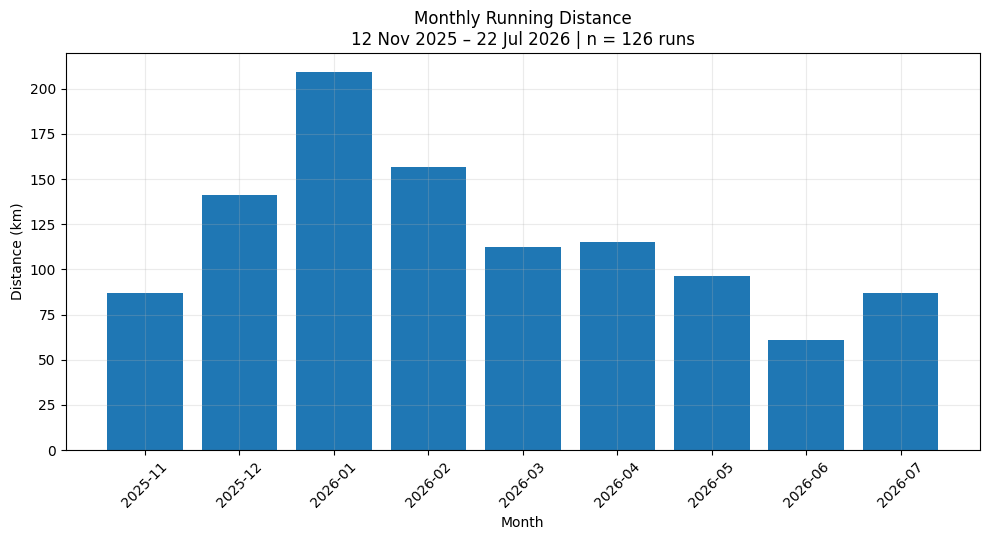

In [85]:
# CELL 16 — VISUAL 1: Monthly Running Distance
# Pertanyaan:
# "Bagaimana volume kilometer lari berubah setiap bulan?"

fig, ax = plt.subplots()

ax.bar(
    monthly["month_label"],
    monthly["total_distance_km"]
)

ax.set_title(
    f"Monthly Running Distance\n{chart_context}"
)
ax.set_xlabel("Month")
ax.set_ylabel("Distance (km)")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(
    CHART_DIR / "01_monthly_running_distance.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

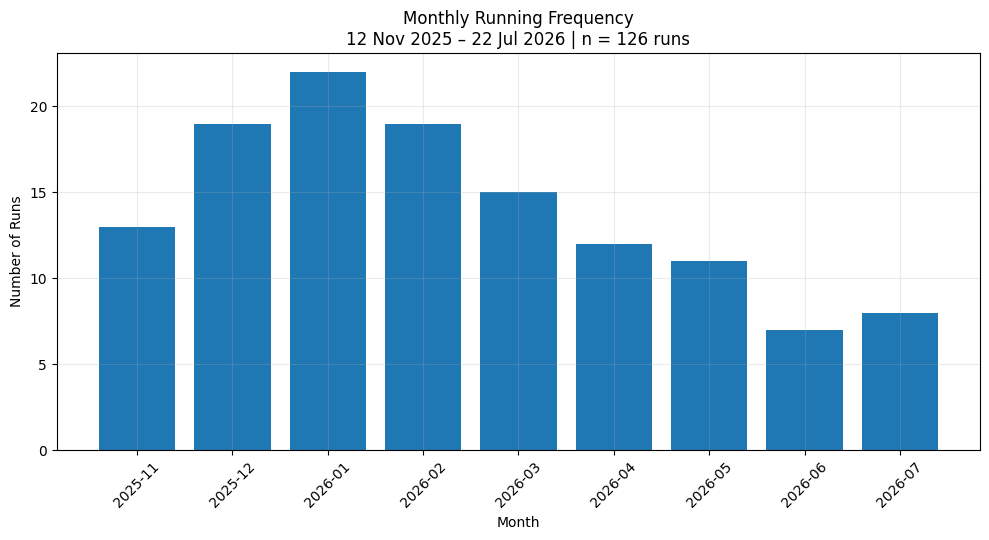

In [86]:
# CELL 17 — VISUAL 2: Monthly Run Frequency
# Pertanyaan:
# "Bagaimana frekuensi aktivitas lari berubah setiap bulan?"

fig, ax = plt.subplots()

ax.bar(
    monthly["month_label"],
    monthly["total_runs"]
)

ax.set_title(
    f"Monthly Running Frequency\n{chart_context}"
)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Runs")
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(
    CHART_DIR / "02_monthly_run_frequency.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

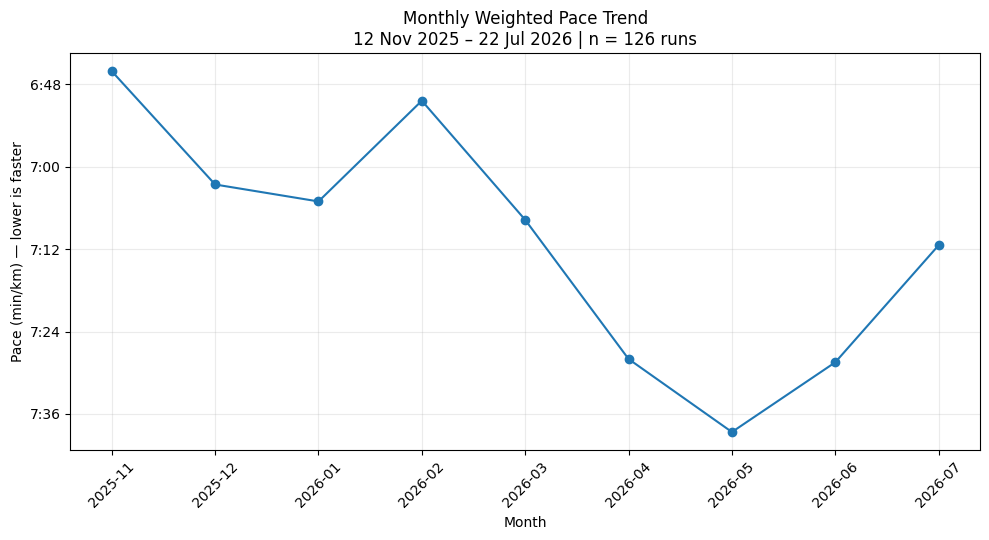

In [87]:
# CELL 18 — VISUAL 3: Monthly Weighted Pace Trend
# Pertanyaan:
# "Bagaimana recorded running pace berubah dari bulan ke bulan?"
#
# Lower pace = lebih cepat, sehingga axis dibalik
# untuk memudahkan interpretasi.

fig, ax = plt.subplots()

ax.plot(
    monthly["month_label"],
    monthly["weighted_pace_min_km"],
    marker="o"
)

ax.set_title(
    f"Monthly Weighted Pace Trend\n{chart_context}"
)
ax.set_xlabel("Month")
ax.set_ylabel("Pace (min/km) — lower is faster")
ax.yaxis.set_major_formatter(pace_formatter)
ax.invert_yaxis()
ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(
    CHART_DIR / "03_monthly_weighted_pace.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

In [88]:
# CELL 19 — ANALISIS 2: Distribusi jarak lari
# Pertanyaan:
# "Jarak seperti apa yang paling sering dilakukan?"
#
# Kita melihat statistik lebih dulu sebelum visualisasi.

distance_summary = runs["distance_km"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9]
)

display(distance_summary.to_frame("distance_km"))



,distance_km
count,126.00
mean,8.46
std,4.19
min,0.45
25%,5.59
50%,9.95
75%,10.07
90%,12.27
max,23.60


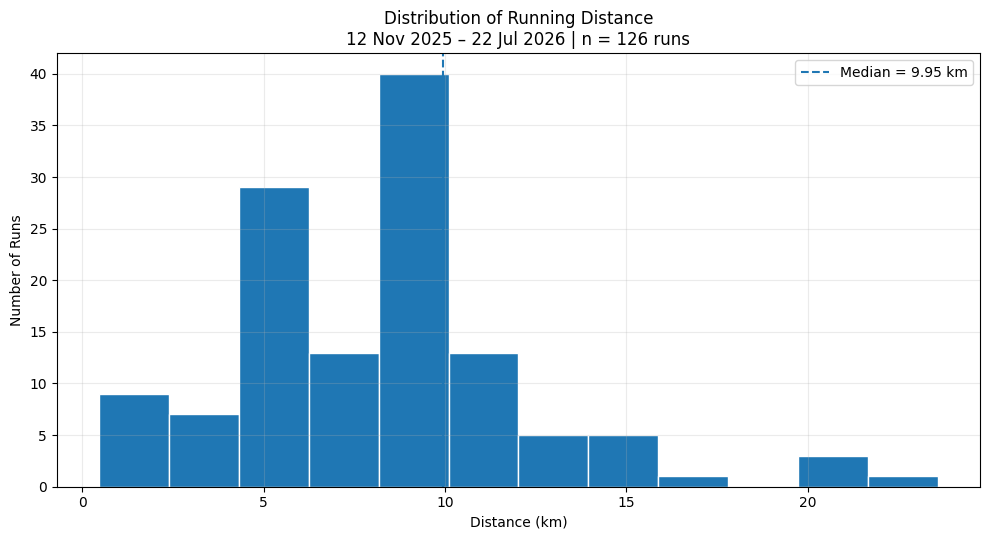

In [89]:
# CELL 20 — VISUAL 4: Running Distance Distribution
# Pertanyaan:
# "Bagaimana distribusi distance per run?"

fig, ax = plt.subplots()

ax.hist(
    runs["distance_km"],
    bins=12,
    edgecolor="white"
)

ax.axvline(
    runs["distance_km"].median(),
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Median = "
        f"{runs['distance_km'].median():.2f} km"
    )
)

ax.set_title(
    f"Distribution of Running Distance\n{chart_context}"
)
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Number of Runs")
ax.legend()

fig.tight_layout()
fig.savefig(
    CHART_DIR / "04_running_distance_distribution.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

In [90]:
# CELL 21 — ANALISIS 3: Running pattern berdasarkan hari
# Pertanyaan:
# "Hari apa yang paling sering digunakan untuk berlari?"

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

runs_by_day = (
    runs["day_name"]
    .value_counts()
    .reindex(day_order, fill_value=0)
)

display(
    runs_by_day
    .rename("total_runs")
    .to_frame()
)



,total_runs
day_name,
Monday,8
Tuesday,18
Wednesday,19
Thursday,15
Friday,19
Saturday,25
Sunday,22


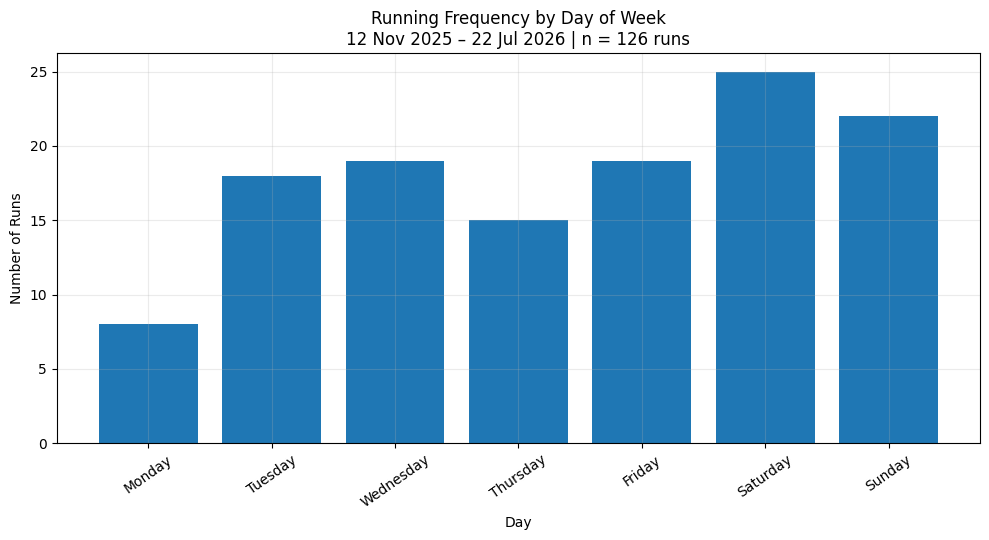

In [91]:
# CELL 22 — VISUAL 5: Runs by Day of Week
# Pertanyaan:
# "Apakah ada pola hari tertentu untuk melakukan aktivitas lari?"

fig, ax = plt.subplots()

ax.bar(
    runs_by_day.index,
    runs_by_day.values
)

ax.set_title(
    f"Running Frequency by Day of Week\n{chart_context}"
)
ax.set_xlabel("Day")
ax.set_ylabel("Number of Runs")
ax.tick_params(axis="x", rotation=35)

fig.tight_layout()
fig.savefig(
    CHART_DIR / "05_runs_by_day_of_week.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

In [92]:
# CELL 23 — ANALISIS 4: Distance vs Pace
# Pertanyaan:
# "Apakah sesi yang lebih panjang cenderung memiliki recorded pace yang berbeda?"
#
# Ini exploratory relationship, BUKAN causal analysis.

correlation_distance_pace = runs[
    ["distance_km", "pace_min_km"]
].corr().iloc[0, 1]

print(
    "Pearson correlation distance vs pace:",
    f"{correlation_distance_pace:.3f}"
)



Pearson correlation distance vs pace: -0.205


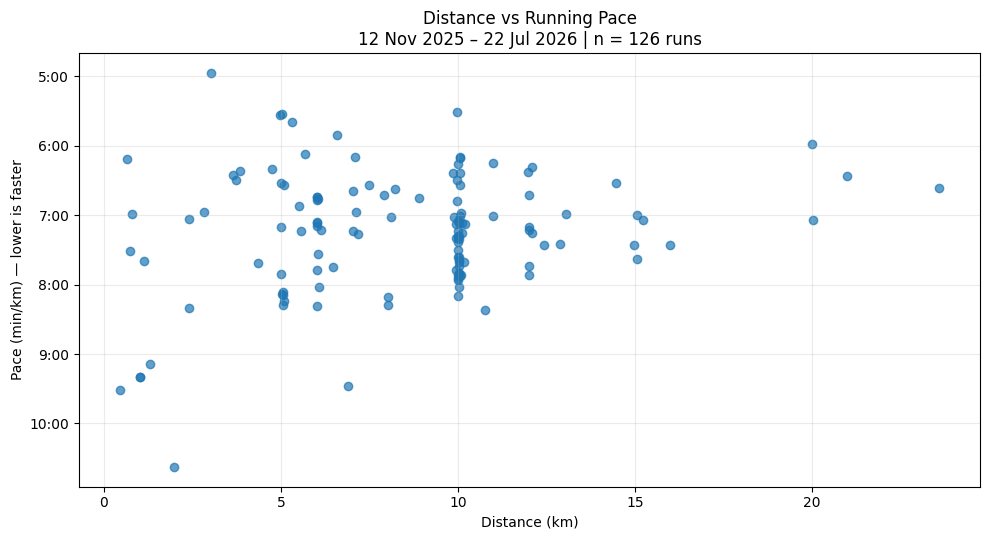

In [93]:
# CELL 24 — VISUAL 6: Distance vs Pace
# Pertanyaan:
# "Bagaimana relationship antara distance dan pace pada activity level?"
#
# Tidak menyimpulkan bahwa distance MENYEBABKAN pace berubah.

fig, ax = plt.subplots()

ax.scatter(
    runs["distance_km"],
    runs["pace_min_km"],
    alpha=0.7
)

ax.set_title(
    f"Distance vs Running Pace\n{chart_context}"
)
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Pace (min/km) — lower is faster")
ax.yaxis.set_major_formatter(pace_formatter)
ax.invert_yaxis()

fig.tight_layout()
fig.savefig(
    CHART_DIR / "06_distance_vs_pace.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

In [94]:
# CELL 25 — ANALISIS 5: Longest Runs
# Pertanyaan:
# "Aktivitas mana yang memiliki distance terpanjang?"
#
# Kita tidak menampilkan Activity Name untuk menjaga output portfolio lebih aman.

top_longest_runs = (
    runs[
        [
            "activity_date",
            "distance_km",
            "moving_time_min",
            "pace_min_km",
        ]
    ]
    .sort_values("distance_km", ascending=False)
    .head(10)
    .copy()
)

top_longest_runs["pace"] = (
    top_longest_runs["pace_min_km"]
    .apply(pace_to_string)
)

display(
    top_longest_runs[
        [
            "activity_date",
            "distance_km",
            "moving_time_min",
            "pace",
        ]
    ]
)



,activity_date,distance_km,moving_time_min,pace
128,2025-12-31,23.60,155.87,6:36 /km
109,2026-01-17,21.01,135.12,6:26 /km
90,2026-02-08,20.03,141.70,7:05 /km
102,2026-01-25,20.00,119.43,5:58 /km
98,2026-02-01,16.00,118.88,7:26 /km
159,2025-11-26,15.24,107.77,7:04 /km
84,2026-02-14,15.06,105.25,6:59 /km
35,2026-04-29,15.05,114.90,7:38 /km
11,2026-07-03,14.98,111.18,7:25 /km
82,2026-02-16,14.48,94.52,6:32 /km


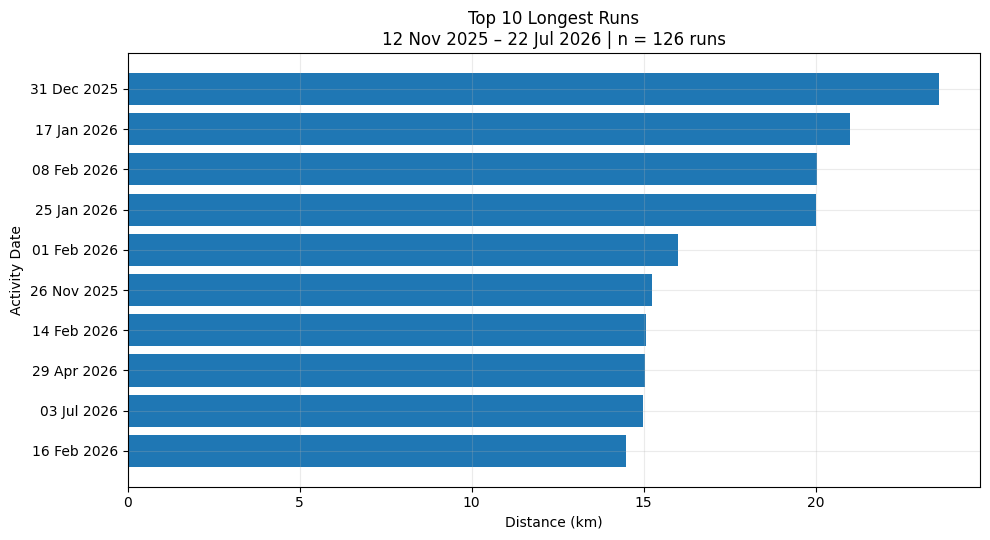

In [95]:
# CELL 26 — VISUAL 7: Top 10 Longest Runs
# Pertanyaan:
# "Bagaimana perbandingan 10 aktivitas lari terpanjang?"

top_longest_plot = (
    top_longest_runs
    .sort_values("distance_km", ascending=True)
)

labels = (
    pd.to_datetime(top_longest_plot["activity_date"])
    .dt.strftime("%d %b %Y")
)

fig, ax = plt.subplots()

ax.barh(
    labels,
    top_longest_plot["distance_km"]
)

ax.set_title(
    f"Top 10 Longest Runs\n{chart_context}"
)
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Activity Date")

fig.tight_layout()
fig.savefig(
    CHART_DIR / "07_top_10_longest_runs.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

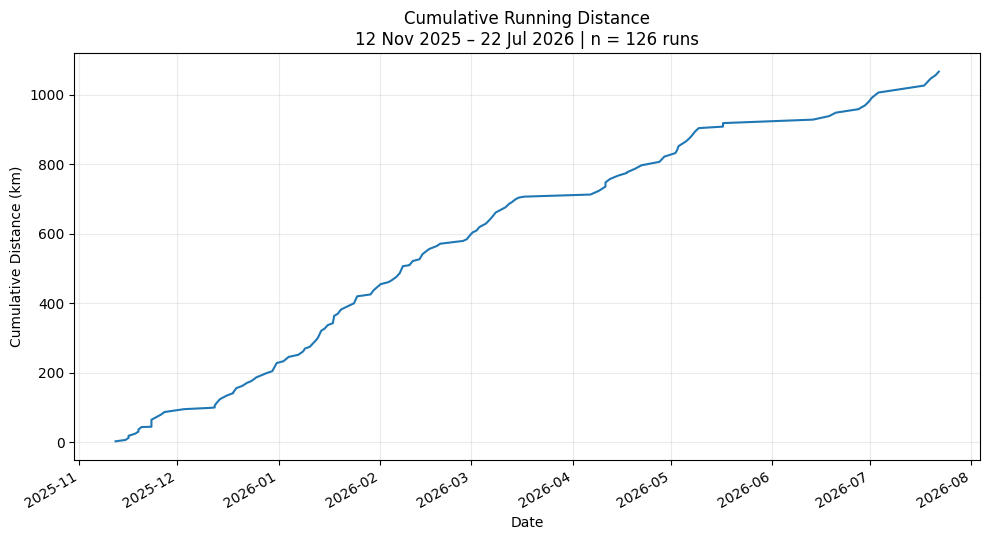

In [96]:
# CELL 27 — VISUAL 8: Cumulative Running Distance
# Pertanyaan:
# "Bagaimana total kilometer terakumulasi sepanjang periode observasi?"
#
# Ini memberi perspektif progression yang berbeda dari monthly chart.

runs_sorted = (
    runs
    .sort_values("activity_datetime")
    .copy()
)

runs_sorted["cumulative_distance_km"] = (
    runs_sorted["distance_km"].cumsum()
)

fig, ax = plt.subplots()

ax.plot(
    runs_sorted["activity_datetime"],
    runs_sorted["cumulative_distance_km"]
)

ax.set_title(
    f"Cumulative Running Distance\n{chart_context}"
)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Distance (km)")

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    CHART_DIR / "08_cumulative_running_distance.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

In [97]:
# CELL 28 — Menghasilkan tabel insight otomatis
# Analisis:
# Mengambil beberapa temuan DESKRIPTIF langsung dari dataset.
# Narasi final tetap perlu Anda tulis dengan bahasa sendiri di README.

peak_distance_row = monthly.loc[
    monthly["total_distance_km"].idxmax()
]

peak_frequency_row = monthly.loc[
    monthly["total_runs"].idxmax()
]

fastest_month_row = monthly.loc[
    monthly["weighted_pace_min_km"].idxmin()
]

most_common_day = runs_by_day.idxmax()
most_common_day_count = runs_by_day.max()

auto_insights = pd.DataFrame({
    "finding": [
        "Highest monthly distance",
        "Highest monthly run frequency",
        "Fastest monthly weighted pace",
        "Most common running day",
        "Longest individual run",
    ],
    "result": [
        (
            f"{peak_distance_row['month_label']} — "
            f"{peak_distance_row['total_distance_km']:.2f} km"
        ),
        (
            f"{peak_frequency_row['month_label']} — "
            f"{int(peak_frequency_row['total_runs'])} runs"
        ),
        (
            f"{fastest_month_row['month_label']} — "
            f"{pace_to_string(fastest_month_row['weighted_pace_min_km'])}"
        ),
        f"{most_common_day} — {int(most_common_day_count)} runs",
        f"{longest_run_km:.2f} km",
    ]
})

display(auto_insights)



,finding,result
0,Highest monthly distance,2026-01 — 209.19 km
1,Highest monthly run frequency,2026-01 — 22 runs
2,Fastest monthly weighted pace,2025-11 — 6:46 /km
3,Most common running day,Saturday — 25 runs
4,Longest individual run,23.60 km


In [98]:
# CELL 29 — Export cleaned/sanitized dataset
# Analisis:
# Menyiapkan dataset aman untuk project portfolio dan V2.
#
# Privacy choices:
# - original Strava Activity ID tidak diekspor
# - Activity Name tidak dipakai
# - time-of-day dibuang; hanya activity_date yang disimpan
# - tidak ada GPS / latitude / longitude
# - tidak ada Filename / FIT path
# - tidak ada profile, contacts, device ID, atau login information
#
# activity_id di bawah adalah SURROGATE ID yang dibuat ulang,
# bukan original Activity ID dari Strava.

public_runs = (
    runs
    .sort_values("activity_datetime")
    .reset_index(drop=True)
    .copy()
)

public_runs.insert(
    0,
    "activity_id",
    np.arange(1, len(public_runs) + 1)
)

public_columns = [
    "activity_id",
    "activity_date",
    "distance_km",
    "moving_time_sec",
    "moving_time_min",
    "pace_min_km",
    "speed_kmh",
    "Elevation Gain",
    "year",
    "month",
    "year_month",
    "day_name",
]

public_runs = (
    public_runs[public_columns]
    .copy()
)

public_runs = public_runs.rename(
    columns={
        "Elevation Gain": "elevation_gain_m"
    }
)

public_runs["year_month"] = (
    public_runs["year_month"].astype(str)
)

clean_output_path = (
    PROCESSED_DIR /
    "activities_run_clean.csv"
)

public_runs.to_csv(
    clean_output_path,
    index=False
)

print(
    "Clean dataset saved: "
    "data/processed/activities_run_clean.csv"
)
print(
    f"Public dataset shape: "
    f"{public_runs.shape[0]:,} rows × "
    f"{public_runs.shape[1]:,} columns"
)

display(public_runs.head())

Clean dataset saved: data/processed/activities_run_clean.csv
Public dataset shape: 126 rows × 12 columns


,activity_id,activity_date,distance_km,moving_time_sec,moving_time_min,pace_min_km,speed_kmh,elevation_gain_m,year,month,year_month,day_name
0,1,2025-11-12,2.83,1180,19.67,6.95,8.63,7.40,2025,11,2025-11,Wednesday
1,2,2025-11-15,3.83,1464,24.40,6.37,9.42,30.80,2025,11,2025-11,Saturday
2,3,2025-11-16,6.02,2565,42.75,7.11,8.45,9.00,2025,11,2025-11,Sunday
3,4,2025-11-16,6.01,2558,42.63,7.09,8.46,0.00,2025,11,2025-11,Sunday
4,5,2025-11-18,6.02,2452,40.87,6.78,8.85,32.00,2025,11,2025-11,Tuesday


In [99]:
# CELL 30 — Export monthly summary
# Analisis:
# Menyiapkan tabel agregasi bulanan yang nanti dapat digunakan ulang
# untuk README dan menjadi jembatan menuju V2.

monthly_export = monthly[
    [
        "month_label",
        "total_distance_km",
        "total_runs",
        "average_distance_km",
        "weighted_pace_min_km",
    ]
].copy()

monthly_export.to_csv(
    PROCESSED_DIR / "monthly_running_summary.csv",
    index=False
)

display(monthly_export)



,month_label,total_distance_km,total_runs,average_distance_km,weighted_pace_min_km
0,2025-11,87.09,13,6.70,6.77
1,2025-12,140.93,19,7.42,7.04
2,2026-01,209.19,22,9.51,7.08
3,2026-02,156.77,19,8.25,6.84
4,2026-03,112.41,15,7.49,7.13
5,2026-04,115.12,12,9.59,7.47
6,2026-05,96.35,11,8.76,7.64
7,2026-06,60.90,7,8.70,7.47
8,2026-07,87.15,8,10.89,7.19


In [100]:
# CELL 31 — Export KPI summary
# Analisis:
# Menyimpan angka inti agar README tidak perlu dihitung manual
# dan definisi metric dapat direkonsiliasi pada versi berikutnya.

summary_metrics = pd.DataFrame({
    "metric": [
        "raw_export_start",
        "raw_export_end",
        "run_analysis_start",
        "run_analysis_end",
        "distance_source",
        "total_runs",
        "total_distance_km",
        "total_running_hours",
        "average_distance_km",
        "median_distance_km",
        "longest_run_km",
        "overall_weighted_pace_min_km",
    ],
    "value": [
        raw_export_start.date(),
        raw_export_end.date(),
        analysis_start.date(),
        analysis_end.date(),
        "Distance.1 / 1000",
        total_runs,
        round(total_distance_km, 4),
        round(total_running_hours, 4),
        round(average_distance_km, 4),
        round(median_distance_km, 4),
        round(longest_run_km, 4),
        round(overall_pace, 6),
    ]
})

summary_metrics.to_csv(
    PROCESSED_DIR / "v1_summary_metrics.csv",
    index=False
)

display(summary_metrics)

,metric,value
0,raw_export_start,2025-11-09
1,raw_export_end,2026-07-22
2,run_analysis_start,2025-11-12
3,run_analysis_end,2026-07-22
4,distance_source,Distance.1 / 1000
5,total_runs,126
6,total_distance_km,"1,065.91"
7,total_running_hours,126.92
8,average_distance_km,8.46
9,median_distance_km,9.95


In [101]:
# CELL 32 — Export data-quality report V1
# Analisis:
# Mendokumentasikan quality checks agar cleaning process transparan.

v1_quality_report = pd.DataFrame({
    "check": [
        "Raw activity rows",
        "Raw columns",
        "Run rows before cleaning",
        "Run rows after cleaning",
        "Duplicate Activity ID before cleaning",
        "Missing Activity Date before cleaning",
        "Missing Moving Time before cleaning",
        "Missing Distance.1 before cleaning",
    ],
    "value": [
        activities_raw.shape[0],
        activities_raw.shape[1],
        rows_before,
        rows_after,
        quality_check.loc[
            quality_check["metric"].eq("Duplicate Activity ID"),
            "value"
        ].iloc[0],
        quality_check.loc[
            quality_check["metric"].eq("Missing Activity Date"),
            "value"
        ].iloc[0],
        quality_check.loc[
            quality_check["metric"].eq("Missing Moving Time"),
            "value"
        ].iloc[0],
        quality_check.loc[
            quality_check["metric"].eq("Missing Distance.1"),
            "value"
        ].iloc[0],
    ]
})

v1_quality_report.to_csv(
    PROCESSED_DIR / "v1_data_quality_report.csv",
    index=False
)

display(v1_quality_report)



,check,value
0,Raw activity rows,185
1,Raw columns,103
2,Run rows before cleaning,126
3,Run rows after cleaning,126
4,Duplicate Activity ID before cleaning,0
5,Missing Activity Date before cleaning,0
6,Missing Moving Time before cleaning,0
7,Missing Distance.1 before cleaning,0


In [102]:
# CELL 33 — Final project checkpoint
# Analisis:
# Memastikan semua output utama V1 berhasil dibuat.

expected_outputs = [
    PROCESSED_DIR / "activities_run_clean.csv",
    PROCESSED_DIR / "monthly_running_summary.csv",
    PROCESSED_DIR / "v1_summary_metrics.csv",
    PROCESSED_DIR / "v1_data_quality_report.csv",
    CHART_DIR / "01_monthly_running_distance.png",
    CHART_DIR / "02_monthly_run_frequency.png",
    CHART_DIR / "03_monthly_weighted_pace.png",
    CHART_DIR / "04_running_distance_distribution.png",
    CHART_DIR / "05_runs_by_day_of_week.png",
    CHART_DIR / "06_distance_vs_pace.png",
    CHART_DIR / "07_top_10_longest_runs.png",
    CHART_DIR / "08_cumulative_running_distance.png",
]

output_check = pd.DataFrame({
    "output": [
        str(path.relative_to(PROJECT_ROOT))
        for path in expected_outputs
    ],
    "exists": [
        path.exists()
        for path in expected_outputs
    ],
})

display(output_check)

if output_check["exists"].all():
    print(
        "V1 analysis pipeline selesai dan "
        "semua output berhasil dibuat."
    )
else:
    print(
        "Ada output yang belum dibuat. "
        "Periksa cell sebelumnya."
    )

,output,exists
0,data/processed/activities_run_clean.csv,True
1,data/processed/monthly_running_summary.csv,True
2,data/processed/v1_summary_metrics.csv,True
3,data/processed/v1_data_quality_report.csv,True
4,images/charts/01_monthly_running_distance.png,True
5,images/charts/02_monthly_run_frequency.png,True
6,images/charts/03_monthly_weighted_pace.png,True
7,images/charts/04_running_distance_distribution...,True
8,images/charts/05_runs_by_day_of_week.png,True
9,images/charts/06_distance_vs_pace.png,True


V1 analysis pipeline selesai dan semua output berhasil dibuat.


## CELL 34 — Interpretation Checklist

Setelah seluruh kode berjalan, tulis insight manual berdasarkan output Anda.

Jawab lima pertanyaan berikut di README:

1. Pada bulan apa running volume paling tinggi?
2. Apakah frekuensi run mengikuti pola yang sama dengan total distance?
3. Bagaimana monthly weighted pace berubah selama periode observasi?
4. Jarak run seperti apa yang paling umum dilakukan?
5. Apakah ada pola hari tertentu untuk melakukan lari?

Hindari klaim seperti:
"fitness meningkat", "training plan efektif", atau "risiko cedera meningkat".

V1 hanya mendukung descriptive/exploratory analysis.
Analisis heart rate, training effort, dan faktor lain masuk ke versi berikutnya.
